<a href="https://colab.research.google.com/github/fur-ruf/data_analysis/blob/main/lab5_mashine.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Лабораторная работа №5
## Градиентный бустинг

Выполнила: Будюкова Полина (408326)

Группа: P3321

Преподаватель: Солодкая Мария Александровна

### Цель работы:
Изучить градиентный бустинг в задаче распознавания человеческой активности.

### Задание:
1. Реализовать градиентный бустинг (выбор гиперпараметров обосновать).
2. Посчитать accuracy, precision, recall, F1-меру.
3. Вывести ROC-кривую.


## Загрузка данных

In [ ]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter

def load_har(path):
    X_train = np.genfromtxt(f"{path}/X_train.txt")
    print(f"X_train shape: {X_train.shape}")
    y_train = np.genfromtxt(f"{path}/y_train.txt") - 1
    X_test = np.genfromtxt(f"{path}/X_test.txt")
    y_test = np.genfromtxt(f"{path}/y_test.txt") - 1
    return (
        torch.tensor(X_train, dtype=torch.float32),
        torch.tensor(y_train, dtype=torch.long),
        torch.tensor(X_test, dtype=torch.float32),
        torch.tensor(y_test, dtype=torch.long),
    )

## Реализация алгоритма

In [ ]:
class DecisionTree:
    def __init__(self, max_depth=3, min_samples=10, max_features=None):
        self.max_depth = max_depth
        self.min_samples = min_samples
        self.max_features = max_features
        self.feature = None
        self.threshold = None
        self.left = None
        self.right = None
        self.value = None

    def _best_split(self, X, y):
        n_samples, n_features = X.shape
        best_mse = float('inf')
        best_feat = None
        best_thr = None

        if self.max_features is None:
            features_to_try = n_features
        else:
            features_to_try = min(self.max_features, n_features)

        indices = torch.randperm(n_features)[:features_to_try]

        for feat_idx in indices:
            feature = X[:, feat_idx]

            unique_vals = torch.unique(feature)
            if len(unique_vals) > 20:
                percentiles = torch.linspace(0, 100, 21)[1:-1]
                thresholds = torch.quantile(feature, percentiles / 100)
            else:
                thresholds = unique_vals

            for thr in thresholds:
                left_mask = feature <= thr
                right_mask = ~left_mask

                if left_mask.sum() < self.min_samples or right_mask.sum() < self.min_samples:
                    continue

                y_left = y[left_mask]
                y_right = y[right_mask]

                mse = (torch.var(y_left) * len(y_left) +
                       torch.var(y_right) * len(y_right)) / n_samples

                if mse < best_mse:
                    best_mse = mse
                    best_feat = feat_idx
                    best_thr = thr

        return best_feat, best_thr

    def fit(self, X, y, depth=0):
        if depth >= self.max_depth or len(y) < self.min_samples or len(torch.unique(y)) == 1:
            self.value = torch.mean(y)
            return

        self.feature, self.threshold = self._best_split(X, y)

        if self.feature is None:
            self.value = torch.mean(y)
            return

        mask = X[:, self.feature] <= self.threshold

        self.left = DecisionTree(self.max_depth, self.min_samples, self.max_features)
        self.right = DecisionTree(self.max_depth, self.min_samples, self.max_features)

        self.left.fit(X[mask], y[mask], depth + 1)
        self.right.fit(X[~mask], y[~mask], depth + 1)

    def predict(self, X):
        n_samples = X.shape[0]
        predictions = torch.zeros(n_samples)

        stack = [(torch.arange(n_samples), self)]

        while stack:
            indices, node = stack.pop()

            if node.value is not None:
                predictions[indices] = node.value
                continue

            left_mask = X[indices, node.feature] <= node.threshold
            right_mask = ~left_mask

            if left_mask.any():
                stack.append((indices[left_mask], node.left))
            if right_mask.any():
                stack.append((indices[right_mask], node.right))

        return predictions


class GradientBoosting:
    def __init__(self, n_estimators=30, max_depth=3, lr=0.1, subsample=0.8,
                 max_features='sqrt', min_samples=10):
        self.n_estimators = n_estimators
        self.max_depth = max_depth
        self.lr = lr
        self.subsample = subsample
        self.max_features = max_features
        self.min_samples = min_samples
        self.trees = []
        self.base = None
        self.n_classes = None

    def _sample(self, n):
        if self.subsample >= 1:
            return torch.arange(n)
        k = int(n * self.subsample)
        return torch.randperm(n)[:k]

    def fit(self, X, y):
        n_samples = X.shape[0]
        n_features = X.shape[1]

        if self.max_features == 'sqrt':
            max_features = int(np.sqrt(n_features))
        elif self.max_features == 'log2':
            max_features = int(np.log2(n_features)) + 1
        elif self.max_features is None:
            max_features = n_features
        else:
            max_features = self.max_features

        self.n_classes = len(torch.unique(y))

        counts = torch.bincount(y)
        probs = counts.float() / n_samples
        self.base = torch.log(probs + 1e-9)

        pred = self.base.repeat(n_samples, 1)

        for iteration in range(self.n_estimators):
            print(f"Итерация {iteration + 1}/{self.n_estimators}", end='\r')

            softmax = torch.softmax(pred, dim=1)
            y_onehot = torch.nn.functional.one_hot(y, self.n_classes).float()
            residuals = y_onehot - softmax

            step_trees = []

            for c in range(self.n_classes):
                idx = self._sample(n_samples)
                X_sub = X[idx]
                r_sub = residuals[idx, c]

                tree = DecisionTree(
                    max_depth=self.max_depth,
                    min_samples=self.min_samples,
                    max_features=max_features
                )
                tree.fit(X_sub, r_sub)
                step_trees.append(tree)

                pred[:, c] += self.lr * tree.predict(X)

            self.trees.append(step_trees)

        print(f"\nОбучение завершено. {self.n_estimators} итераций")

    def predict_proba(self, X):
        n_samples = X.shape[0]
        pred = self.base.repeat(n_samples, 1)

        for step in self.trees:
            for c, tree in enumerate(step):
                pred[:, c] += self.lr * tree.predict(X)

        return torch.softmax(pred, dim=1)

    def predict(self, X):
        return torch.argmax(self.predict_proba(X), dim=1)

## Метрики

In [ ]:
def calculate_metrics(y_true, y_pred, n_classes=6):
    confusion = torch.zeros(n_classes, n_classes)
    for t, p in zip(y_true, y_pred):
        confusion[t, p] += 1

    precisions = []
    recalls = []
    f1_scores = []

    for c in range(n_classes):
        tp = confusion[c, c]
        fp = confusion[:, c].sum() - tp
        fn = confusion[c, :].sum() - tp

        precision = tp / (tp + fp + 1e-9)
        recall = tp / (tp + fn + 1e-9)
        f1 = 2 * precision * recall / (precision + recall + 1e-9)

        precisions.append(precision)
        recalls.append(recall)
        f1_scores.append(f1)

    return {
        'accuracy': confusion.trace() / confusion.sum(),
        'precision': torch.tensor(precisions).mean().item(),
        'recall': torch.tensor(recalls).mean().item(),
        'f1': torch.tensor(f1_scores).mean().item(),
        'per_class': {
            'precision': precisions,
            'recall': recalls,
            'f1': f1_scores
        }
    }

## ROC-кривая

In [ ]:
def plot_roc_curve(model, X_test, y_test, n_classes=6):
    probs = model.predict_proba(X_test).numpy()
    y_test_np = y_test.numpy()

    plt.figure(figsize=(10, 8))

    for c in range(n_classes):

        y_binary = (y_test_np == c).astype(int)
        scores = probs[:, c]

        desc_indices = np.argsort(scores)[::-1]
        y_sorted = y_binary[desc_indices]

        tpr = np.cumsum(y_sorted) / (y_binary.sum() + 1e-9)
        fpr = np.cumsum(1 - y_sorted) / ((1 - y_binary).sum() + 1e-9)

        fpr = np.concatenate([[0], fpr, [1]])
        tpr = np.concatenate([[0], tpr, [1]])

        auc = np.trapz(tpr, fpr)

        plt.plot(fpr, tpr, label=f'Class {c} (AUC = {auc:.3f})', linewidth=2)

    plt.plot([0, 1], [0, 1], 'k--', linewidth=1)
    plt.xlabel('False Positive Rate', fontsize=12)
    plt.ylabel('True Positive Rate', fontsize=12)
    plt.title('ROC Curves - Human Activity Recognition', fontsize=14)
    plt.legend(loc='lower right')
    plt.grid(alpha=0.3)
    plt.show()

## Основная часть

X_train shape: (7352, 561)

Обучение завершено. 30 итераций
Результаты:
Accuracy:  0.8850
Precision: 0.8909
Recall:    0.8792
F1-score:  0.8810

Метрики для каждого класса:
  Class 0: P=0.802, R=0.964, F1=0.875
  Class 1: P=0.902, R=0.864, F1=0.883
  Class 2: P=0.924, R=0.752, F1=0.829
  Class 3: P=0.902, R=0.772, F1=0.832
  Class 4: P=0.824, R=0.923, F1=0.871
  Class 5: P=0.991, R=1.000, F1=0.995


/tmp/ipykernel_1507/2362806896.py:21: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  auc = np.trapz(tpr, fpr)


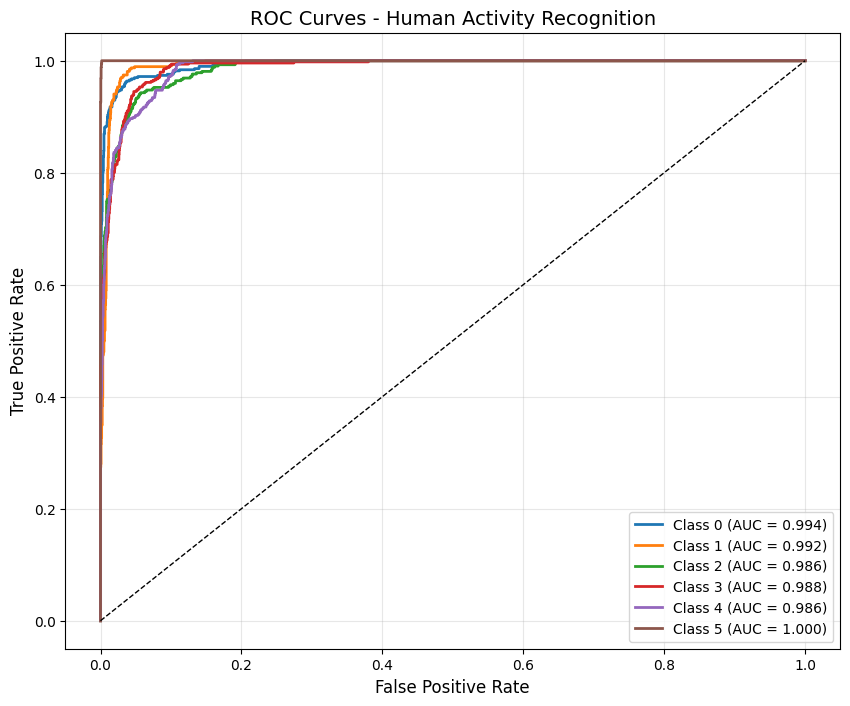

In [ ]:
path = "sample_data"
X_train, y_train, X_test, y_test = load_har(path)


model = GradientBoosting(
    n_estimators=30,
    max_depth=3,
    lr=0.1,
    subsample=0.8,
    max_features='sqrt',
    min_samples=10
)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

metrics = calculate_metrics(y_test, y_pred)
print("Результаты:")
print("="*50)
print(f"Accuracy:  {metrics['accuracy']:.4f}")
print(f"Precision: {metrics['precision']:.4f}")
print(f"Recall:    {metrics['recall']:.4f}")
print(f"F1-score:  {metrics['f1']:.4f}")
print("\nМетрики для каждого класса:")
for c in range(6):
    print(f"  Class {c}: P={metrics['per_class']['precision'][c]:.3f}, "
          f"R={metrics['per_class']['recall'][c]:.3f}, "
          f"F1={metrics['per_class']['f1'][c]:.3f}")

plot_roc_curve(model, X_test, y_test)